In [5]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import random 

/Users/dtx/Git/dyna-ai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


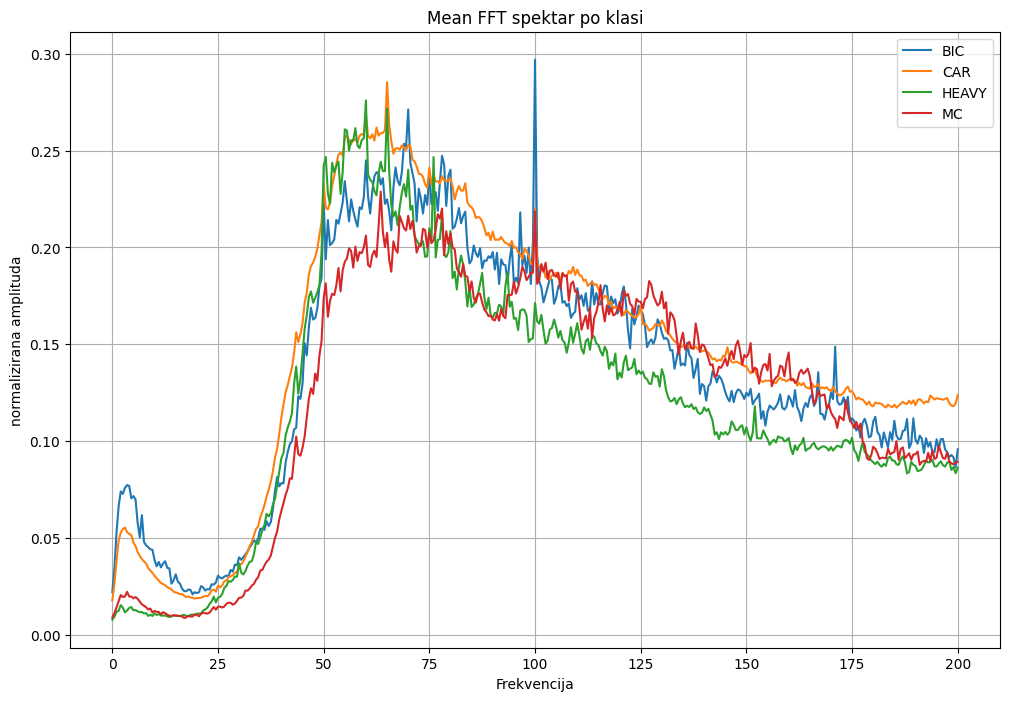

In [7]:
base_path = '../../data/all_sorted'
classes = ['BIC', 'CAR', 'HEAVY', 'MC']

# Sto tu radimo? - funkcija koja računa i prikazuje prosječni FFT spektar po klasama, 
# s mogućnošću zoomiranja na određeni raspon frekvencija.
def mean_fft_per_class_zoom(base_path, classes, max_freq=200):
    plt.figure(figsize=(12, 8))
    
    for label in classes:
        folder = os.path.join(base_path, label)
        files = [f for f in os.listdir(folder) if f.endswith('.wav')]
        
        spectra = []
        
        for file in files:
            path = os.path.join(folder, file)
            y, sr = librosa.load(path, sr=22050)
            y = y[:sr*3]
            
            fft = np.abs(np.fft.rfft(y))
            fft = fft / np.max(fft)  # normalizacija
            
            freqs = np.fft.rfftfreq(len(y), 1/sr)
            
            spectra.append(fft)
        
        min_len = min(len(s) for s in spectra)
        spectra = [s[:min_len] for s in spectra]
        
        mean_spectrum = np.mean(spectra, axis=0)
        
        mask = freqs[:min_len] <= max_freq
        
        plt.plot(freqs[:min_len][mask], mean_spectrum[mask], label=label)
    
    plt.title(f"Mean FFT spektar po klasi")
    plt.xlabel("Frekvencija")
    plt.ylabel("normalizirana amplituda")
    plt.legend()
    plt.grid()
    plt.show()

mean_fft_per_class_zoom(base_path, classes, max_freq=200)